In [37]:
import pydicom as dicom
import matplotlib.pylab as plt
import pandas as pd
import os
import numpy as np
import cv2
from skimage.transform import hough_line, hough_line_peaks, probabilistic_hough_line
from skimage.feature import canny
from skimage.draw import line as draw_line
from skimage import data
from matplotlib import cm
from skimage import exposure


In [24]:
# vamos começar por fazer o image_path
excel = pd.read_csv('metadata\\metadata.csv')
n = 0
# image_path = {}
# ficheiro = {}
full_path = {}
for line in excel.index:
        image_path = os.path.join('D:\\', 'teste',
                                        'cbis_ddsm',
                                        excel.loc[line, excel.columns[0]],
                                        excel.loc[line, excel.columns[1]],
                                        excel.loc[line, excel.columns[2]])
        ficheiro = os.listdir(os.path.join(image_path))[0]
        full_path[n] = os.path.join(image_path, ficheiro)
        n += 1

# df = pd.DataFrame(list(full_path.items()), columns=["full_path", "patient_id", "left_or_right_breast","breast_density", "image_view", "assessment"])
#image_path = 'b39bc242-61d0-46b1-b56d-0bf721f10007.dcm'
# ds = dicom.dcmread(image_path)
# plt.imshow(ds.pixel_array)

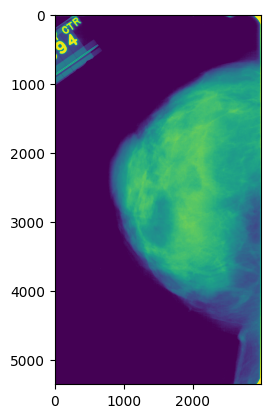

In [35]:
ds = dicom.dcmread("D:\\teste\\cbis_ddsm\\Calc-Training_P_00007_LEFT_CC\\1.3.6.1.4.1.9590.100.1.2.201322325113694962619881476352450072222\\1.3.6.1.4.1.9590.100.1.2.228699627313487111012474405462022068297\\d6536189-e9ad-49c7-8195-f4159f22ca3c.dcm")
plt.imshow(ds.pixel_array)

In [ ]:
database_com_tudo = pd.read_csv('D:\\DAC2\\calc_case_description_train_set.csv')
# data = {}
# for i in full_path:
#         idx = database[database["image file path"].str.contains(full_path[i], na=False, regex=False)].index[0] 
#         data[i] = [full_path[i], database.loc[idx, "patient_id"], database.loc[idx, "left or right breast"], database.loc[idx, "breast density"], database.loc[idx, "image view"], database.loc[idx, "assessment"]]
        
# df = pd.DataFrame(data, columns=["full_path", "patient_id", "left_or_right_breast","breast_density", "image_view", "assessment"])

data = {}
for i in full_path:
    normalised_full = full_path[i].replace("\\", "/")
    normalised_full = "/".join(normalised_full.split("/")[-4:-1])  # Get the last four parts of the path (e.g., "patient_id/image_file.dcm")

    
    matches = database_com_tudo[database_com_tudo["image file path"].apply(
        lambda x: normalised_full in str(x).replace("\\", "/")
    )]
    
    if len(matches) == 0:
        print(f"No match found for: {normalised_full}")
        continue
    
    idx = matches.index[0]
    data[i] = [full_path[i], database_com_tudo.loc[idx, "patient_id"], database_com_tudo.loc[idx, "left or right breast"], database_com_tudo.loc[idx, "image view"], database_com_tudo.loc[idx, "breast density"], database_com_tudo.loc[idx, "assessment"]]

#df é a base de dados q vamos usar!!
df = pd.DataFrame.from_dict(data, orient='index', columns=["full_path", "patient_id", "left_or_right_breast","image_view", "breast_density", "assessment"])
#ordenar df pelo patient_id?


Já temos a base de dados como deve ser, no df

In [ ]:
def cut_pectoral_muscle(pixel_array):
    img = pixel_array.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min())

    img_eq = exposure.equalize_adapthist(img)
    img_uint8 = (img_eq * 255).astype(np.uint8)

    top_third = img_uint8[:img.shape[0] // 3, :]
    edges = canny(top_third.astype(float), sigma=3, low_threshold=5, high_threshold=15)

    lines = probabilistic_hough_line(edges, threshold=5, line_length=20, line_gap=10)

    print(f"Linhas encontradas: {len(lines)}")

    # Mostrar todos os ângulos encontrados para debug
    for (x0, y0), (x1, y1) in lines:
        if x1 != x0:
            angle = np.degrees(np.arctan2(abs(y1-y0), abs(x1-x0)))
            print(f"  ângulo: {angle:.1f}°, comprimento: {np.sqrt((x1-x0)**2 + (y1-y0)**2):.1f}")

    best_line = None
    best_score = -np.inf
    for (x0, y0), (x1, y1) in lines:
        if x1 == x0:
            continue
        length = np.sqrt((x1-x0)**2 + (y1-y0)**2)
        angle = np.degrees(np.arctan2(abs(y1-y0), abs(x1-x0)))
        if 20 < angle < 85 and length > best_score:
            best_score = length
            best_line = ((x0, y0), (x1, y1))

    if best_line is None:
        print("Nenhuma linha encontrada — a devolver imagem original")
        return img_uint8, None

    (x0, y0), (x1, y1) = best_line

    left_pixels  = np.sum(img_uint8[:, :img.shape[1]//2] > 20)
    right_pixels = np.sum(img_uint8[:, img.shape[1]//2:] > 20)
    breast_on_left = left_pixels > right_pixels

    mask = np.ones_like(img_uint8, dtype=np.uint8) * 255
    if x1 != x0:
        slope = (y1 - y0) / (x1 - x0)
        intercept = y0 - slope * x0
        for y in range(img.shape[0]):
            x = int((y - intercept) / (slope + 1e-8))
            x = np.clip(x, 0, img.shape[1])
            if breast_on_left:
                mask[y, :x] = 0
            else:
                mask[y, x:] = 0

    _, bg_mask = cv2.threshold(img_uint8, 10, 255, cv2.THRESH_BINARY)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(bg_mask)
    largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    bg_mask = (labels == largest).astype(np.uint8) * 255

    final_mask = cv2.bitwise_and(mask, bg_mask)
    result = cv2.bitwise_and(img_uint8, img_uint8, mask=final_mask)
    return result, best_line

Linhas encontradas: 1880
  ângulo: 3.7°, comprimento: 47.1
  ângulo: 4.9°, comprimento: 35.1
  ângulo: 6.6°, comprimento: 26.2
  ângulo: 42.3°, comprimento: 44.6
  ângulo: 25.5°, comprimento: 72.0
  ângulo: 49.2°, comprimento: 29.1
  ângulo: 45.0°, comprimento: 39.6
  ângulo: 84.3°, comprimento: 20.1
  ângulo: 31.0°, comprimento: 81.6
  ângulo: 4.1°, comprimento: 28.1
  ângulo: 76.0°, comprimento: 20.6
  ângulo: 37.1°, comprimento: 61.4
  ângulo: 0.0°, comprimento: 25.0
  ângulo: 11.7°, comprimento: 29.6
  ângulo: 27.1°, comprimento: 46.1
  ângulo: 15.6°, comprimento: 26.0
  ângulo: 7.7°, comprimento: 52.5
  ângulo: 36.0°, comprimento: 63.0
  ângulo: 7.1°, comprimento: 24.2
  ângulo: 57.7°, comprimento: 35.5
  ângulo: 68.6°, comprimento: 24.7
  ângulo: 16.7°, comprimento: 31.3
  ângulo: 11.8°, comprimento: 63.3
  ângulo: 49.9°, comprimento: 172.5
  ângulo: 33.7°, comprimento: 32.4
  ângulo: 15.4°, comprimento: 60.2
  ângulo: 51.5°, comprimento: 43.4
  ângulo: 59.0°, comprimento: 29.2
 

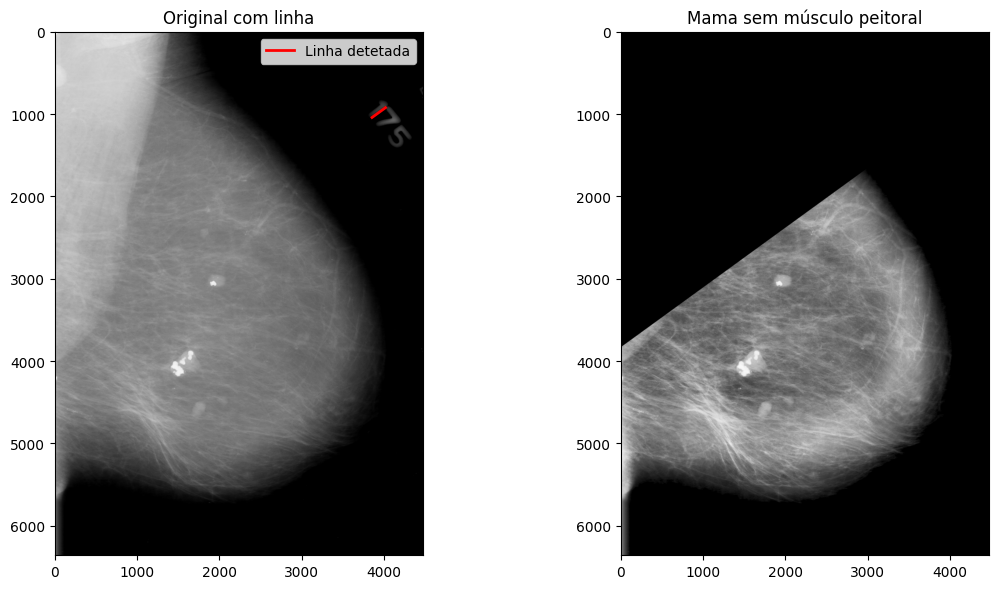

In [51]:
dcm = dicom.dcmread("D:\\teste\\cbis_ddsm\\Calc-Training_P_02584_LEFT_MLO\\1.3.6.1.4.1.9590.100.1.2.234695147113923706734547452500320590579\\1.3.6.1.4.1.9590.100.1.2.197835155813429240930949618151320539237\\b022987b-eae5-483c-b246-41b81c4d5287.dcm")
result, line = cut_pectoral_muscle(dcm.pixel_array)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(dcm.pixel_array, cmap="gray")
if line:
    (x0, y0), (x1, y1) = line
    axes[0].plot([x0, x1], [y0, y1], 'r-', linewidth=2, label="Linha detetada")
    axes[0].legend()
axes[0].set_title("Original com linha")
axes[1].imshow(result, cmap="gray")
axes[1].set_title("Mama sem músculo peitoral")
plt.tight_layout()
plt.show()